## Setup

In [2]:
import pandas as pd
import numpy as np

# regressao

In [3]:
df_test = pd.read_csv('regressao/test.csv')
df_train = pd.read_csv('regressao/train.csv')


df_train.info()
df_train.describe()
df_train.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    str    
 1   sex         395 non-null    str    
 2   age         395 non-null    int64  
 3   address     395 non-null    str    
 4   famsize     395 non-null    str    
 5   Pstatus     395 non-null    str    
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    str    
 9   Fjob        395 non-null    str    
 10  reason      395 non-null    str    
 11  guardian    395 non-null    str    
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    str    
 16  famsup      395 non-null    str    
 17  paid        395 non-null    str    
 18  activities  395 non-null    str    
 19  nursery     395 non-null    str    
 20 

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
score         0
dtype: int64

### separacao por tipo

In [4]:
# colunas numericas
colunas_numericas = df_train.select_dtypes(include= np.number).columns.tolist()
colunas_numericas.remove('score')

# colunas categoricas
colunas_categoricas = df_train.select_dtypes(include='object').columns.tolist()


print('Colunas numericas: ', colunas_numericas)
print('Colunas categoricas: ', colunas_categoricas)

# numericas categoricas (ordinais: que sao representadas como numericas, mas que na verdade sAo categoricas)
falsas_numericas = ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']

# separar as falsas numericas (numericas ordinarias) das numericas reais (numericas continuas)
colunas_numericas = [c for c in colunas_numericas if c not in falsas_numericas]
colunas_categoricas_ordinais = falsas_numericas

print('Colunas numericas reais: ', colunas_numericas)
print('Colunas categoricas ordinais: ', colunas_categoricas_ordinais)

Colunas numericas:  ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Colunas categoricas:  ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Colunas numericas reais:  ['age', 'absences']
Colunas categoricas ordinais:  ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']


/tmp/ipykernel_5500/1001743685.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df_train.select_dtypes(include='object').columns.tolist()


## pre processamento

In [5]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split


preprocessor = ColumnTransformer(
    transformers=[
    ('num', StandardScaler(), colunas_numericas + colunas_categoricas_ordinais),
    ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas),
])

# train split

X = df_train.drop('score', axis=1)
y = df_train['score']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)

(316, 30) (79, 30)


## baseline
modelo mais simples (regressao linear)

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error


modelo_linear = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

modelo_linear.fit(X_train, y_train)
predicoes = modelo_linear.predict(X_val)

RMSE_linear = root_mean_squared_error(y_val, predicoes)

print(RMSE_linear)

3.3749658534077005


## random forest

In [7]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

modelo_rf.fit(X_train, y_train)
predicoes_rf = modelo_rf.predict(X_val)

RMSE_rf = root_mean_squared_error(y_val, predicoes_rf)
print(RMSE_rf)

3.2479281815538426


## gradient boosting

In [8]:
from sklearn.ensemble import GradientBoostingRegressor

modelo_gb = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

modelo_gb.fit(X_train, y_train)
predicoes_gb = modelo_gb.predict(X_val)

RMSE_gb = root_mean_squared_error(y_val, predicoes_gb)
print(RMSE_gb)

3.2758938616214923


### conlusao:

- modelo com maior nota de acordo com a Metrica de acordo com os dados de teste: Regressao Linear

## treinar modelo com todos os dados de treino

In [28]:
# Retreinar o modelo linear com 100% dos dados de treino (igual fizemos com o RandomForest e GradientBoosting)
modelo_linear_final = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

modelo_linear_final.fit(X, y)

predicoes_linear_final = modelo_linear_final.predict(df_test)

submission_linear = pd.DataFrame({'ID': df_test.index, 'Score': predicoes_linear_final})
submission_linear.to_csv('submission_linear.csv', index=False)

submission_linear.head()

,ID,Score
0,0,10.785186
1,1,11.589991
2,2,10.817805
3,3,11.174213
4,4,10.096524


### Notas de submissao no Kaggle:

Regressao Linear:   7.15668

Random Forest:      7.02018

Gradient Boosting:  6.87133



### Conclusao Final:

O Modelo que se saiu melhor dentro deste conjunto de dados foi o mais simples, Regressao linear.

# Classificacao

In [15]:
df_train2 = pd.read_csv('classiicacao/train2.csv')
df_test2 = pd.read_csv('classiicacao/test2.csv') 

df_train2.info()
df_train2.describe()
df_train2.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [16]:
df_train2['diagnosis'].value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

In [17]:
colunas_numericas_clf = df_train2.select_dtypes(include= np.number).columns.tolist()
print('Colunas numericas: ', colunas_numericas_clf)
print(df_train2.dtypes.value_counts())

Colunas numericas:  ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
float64    30
str         1
Name: count, dtype: int64


In [18]:
X_clf = df_train2.drop('diagnosis', axis=1)
y_clf = df_train2['diagnosis'].map({'M': 1, 'B': 0})  # converte para binario (maligno= 1, benigno=0)


## processor

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas_clf)]### Interpretação:

O modelo de Regressão Logística, na validação interna, classificou corretamente 
70 casos benignos e 41 malignos, tendo 1 falso positivo (benigno previsto como 
maligno) e 2 falsos negativos (maligno previsto como benigno). Este último é o 
erro mais preocupante clinicamente, pois representa um caso de câncer que não 
seria encaminhado a tratamento.
)

In [20]:
from sklearn.model_selection import train_test_split

X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

## Baseline
Modelo mais simples (regressao logistica)

In [21]:
# logistic regression


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

modelo_logistic = Pipeline([
    ('prep', preprocessor_clf),
    ('model', LogisticRegression(random_state=42))
])

modelo_logistic.fit(X_train_clf, y_train_clf)
predicoes_logistic = modelo_logistic.predict(X_val_clf)

accuracy_logistic = accuracy_score(y_val_clf, predicoes_logistic)
print(accuracy_logistic)

0.9736842105263158


In [22]:
# random forest classifier

from sklearn.ensemble import RandomForestClassifier

modelo_rf_clf = Pipeline([
    ('prep', preprocessor_clf),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

modelo_rf_clf.fit(X_train_clf, y_train_clf)
predicoes_rf_clf = modelo_rf_clf.predict(X_val_clf)
accuracy_rf_clf = accuracy_score(y_val_clf, predicoes_rf_clf)

print(accuracy_rf_clf)

0.9649122807017544


In [23]:
# gradientBoosting

from sklearn.ensemble import GradientBoostingClassifier

modelo_gb_clf = Pipeline([
    ('prep', preprocessor_clf),
    ('model', GradientBoostingClassifier(random_state=42))
])

modelo_gb_clf.fit(X_train_clf, y_train_clf)
predicoes_gb_clf = modelo_gb_clf.predict(X_val_clf)
accuracy_gb_clf = accuracy_score(y_val_clf, predicoes_gb_clf)

print(accuracy_gb_clf)

0.956140350877193


[[70  1]
 [ 2 41]]


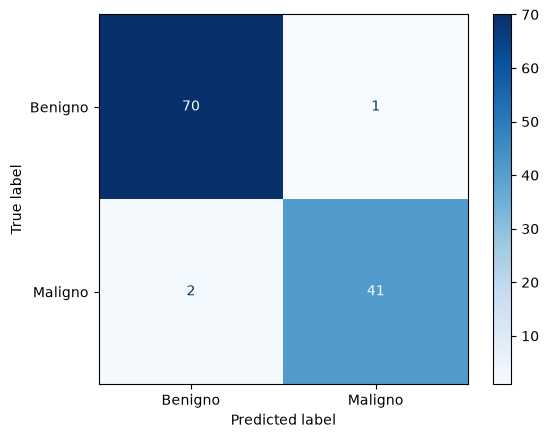

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val_clf, predicoes_logistic)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno']).plot(cmap='Blues')
plt.show()


### Interpretação:

O modelo de Regressão Logística, na validação interna, classificou corretamente 70 casos benignos e 41 malignos, tendo 1 falso positivo (benigno previsto como 
maligno) e 2 falsos negativos (maligno previsto como benigno). Este último e o  erro mais preocupante clinicamente, pois representa um caso de cancer que nao 
seria encaminhado a tratamento.

In [ ]:
#modelo final

modelo_final_clf = Pipeline([
    ('prep', preprocessor_clf),
    ('model', LogisticRegression(random_state=42))
])

modelo_final_clf.fit(X_clf, y_clf)

predicoes_final_clf = modelo_final_clf.predict(df_test2)

submission_clf = pd.DataFrame({'id': df_test2.index, 'diagnosis': predicoes_final_clf})
submission_clf.head()


submission_clf.to_csv('submission_classificacao.csv', index=False)


Tudo certo!


### Notas de submissao no Kaggle:

Regressao Logistica:    0.87500

Gradiente Boosting:     0.85000

Random Forest:          0.85000


## Conclusao:

Novamente, o modelo mais simples (regressao logistica), nesse conjunto de dados, foi o com mais acuracia.

# Conclusao Geral:

Os modelos mais simples, em ambos os casos, foram os que tiveram maior acuracia entre os outros (random forest e gradient boosting), devido a distribuicao dos dados da competicao